# HW4: Palmer Penguins — Summary Statistics & Plots
# Nitin Kunaparaju

### Setup

- Use only `pandas`, `matplotlib`, and `seaborn`.
- Do your work in the cells provided; you may add extra cells.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# (Optional) nicer display for DataFrames
pd.set_option("display.max_columns", 50)
pd.set_option("display.precision", 3)


In [2]:
### Load the dataset
penguins = pd.read_csv("penguins.csv")

# Standardize column names (snake_case)
penguins.columns = [c.strip().lower().replace(' ', '_') for c in penguins.columns]

penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


### Part 1) Data Vitals

Answer the following questions.

Your answer to each question must include some code that produces the result. You can, but you do not have to use a complete sentence to answer each question. Add cells as needed.

- a. What is the shape of the data?
- b. What are the Column names and data types of each column?
- c. How many values in each column are missing?
- d. How many penguins are there of each species? How many male and female penguins are there?

In [3]:
# Your code here
penguins.shape


(344, 8)

In [4]:

penguins.dtypes

species                  str
island                   str
bill_length_mm       float64
bill_depth_mm        float64
flipper_length_mm    float64
body_mass_g          float64
sex                      str
year                   int64
dtype: object

In [5]:
penguins.columns

Index(['species', 'island', 'bill_length_mm', 'bill_depth_mm',
       'flipper_length_mm', 'body_mass_g', 'sex', 'year'],
      dtype='str')

In [6]:

null_species = penguins['species'].isnull().sum()
null_islands = penguins['island'].isnull().sum()
null_bill_length = penguins['bill_length_mm'].isnull().sum()
null_bill_depth = penguins['bill_depth_mm'].isnull().sum()
null_flipper_length = penguins['flipper_length_mm'].isnull().sum()
null_body_mass = penguins['body_mass_g'].isnull().sum()
null_sex = penguins['sex'].isnull().sum()
null_year = penguins['year'].isnull().sum()

print("There are " + str(null_species) + " missing species obersvations")
print("There are " + str(null_islands) + " missing islands observations")
print("There are " + str(null_bill_length) + " missing bill lenght obervations")
print("There are " + str(null_bill_depth) + " missing bill depth observations")
print("There are " + str(null_flipper_length) + " missing flipper length observations")
print("There are " + str(null_body_mass) + " missing body mass observations")
print("There are " + str(null_sex) + " missing sex observations")
print("There are " + str(null_year) + " missing year observations")


There are 0 missing species obersvations
There are 0 missing islands observations
There are 2 missing bill lenght obervations
There are 2 missing bill depth observations
There are 2 missing flipper length observations
There are 2 missing body mass observations
There are 11 missing sex observations
There are 0 missing year observations


In [7]:

penguins['species'].value_counts()

species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64

In [8]:
penguins['sex'].value_counts()

sex
male      168
female    165
Name: count, dtype: int64

### Part 2) Handle missing data

- a. Create a copy `penguins_clean` that **drops** rows with missing values in
   `['bill_length_mm','bill_depth_mm','flipper_length_mm','body_mass_g','sex']`.  
- b. Report the new shape of `penguins_clean`.


In [9]:
penguins_clean = penguins.dropna()
penguins_clean.shape


(333, 8)

### Part 3) Numeric summary statistics

- a. Compute the following **for each numeric column**: count, mean, std, min, 25%, 50%, 75%, max (hint: `.describe()`)
- b. Compute the mean and std for each numeric column for each `species`

In [10]:
penguins_clean.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,male,2007


In [11]:
print(penguins_clean[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'year']].describe())

       bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g      year
count         333.000        333.000            333.000      333.000   333.000
mean           43.993         17.165            200.967     4207.057  2008.042
std             5.469          1.969             14.016      805.216     0.813
min            32.100         13.100            172.000     2700.000  2007.000
25%            39.500         15.600            190.000     3550.000  2007.000
50%            44.500         17.300            197.000     4050.000  2008.000
75%            48.600         18.700            213.000     4775.000  2009.000
max            59.600         21.500            231.000     6300.000  2009.000


In [12]:

print(penguins_clean.groupby('species')[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'year']].describe())

          bill_length_mm                                                    \
                   count    mean    std   min     25%    50%     75%   max   
species                                                                      
Adelie             146.0  38.824  2.663  32.1  36.725  38.85  40.775  46.0   
Chinstrap           68.0  48.834  3.339  40.9  46.350  49.55  51.075  58.0   
Gentoo             119.0  47.568  3.106  40.9  45.350  47.40  49.600  59.6   

          bill_depth_mm                                                 \
                  count    mean    std   min   25%    50%    75%   max   
species                                                                  
Adelie            146.0  18.347  1.219  15.5  17.5  18.40  19.00  21.5   
Chinstrap          68.0  18.421  1.135  16.4  17.5  18.45  19.40  20.8   
Gentoo            119.0  14.997  0.986  13.1  14.2  15.00  15.75  17.3   

          flipper_length_mm                                              \
           

### Part 4) Two-way grouped summaries

a) For each **(species, sex)** combination, compute the **mean** and **count** of:
- `bill_length_mm`, `bill_depth_mm`, `flipper_length_mm`, `body_mass_g`.

b) Which (species, sex) has the **largest average body_mass_g**? Show the row.



In [13]:
# Your code here
grouped_penguins = penguins_clean.groupby(['species', 'sex'])[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']].describe()
max_mass = grouped_penguins['body_mass_g']['max'].max()
print(grouped_penguins[grouped_penguins['body_mass_g']['max'] == max_mass])

             bill_length_mm                                               \
                      count    mean    std   min   25%   50%   75%   max   
species sex                                                                
Gentoo  male           61.0  49.474  2.721  44.4  48.1  49.5  50.5  59.6   

             bill_depth_mm                                               \
                     count    mean    std   min   25%   50%   75%   max   
species sex                                                               
Gentoo  male          61.0  15.718  0.741  14.1  15.2  15.7  16.1  17.3   

             flipper_length_mm                                              \
                         count     mean    std    min    25%    50%    75%   
species sex                                                                  
Gentoo  male              61.0  221.541  5.673  208.0  218.0  221.0  225.0   

                    body_mass_g                                             \
   

### Part 5) Correlations

- a. Compute the **correlation matrix** among numeric columns.  
- b. Compute the correlation matrix **within each species** (hint: groupby).  
- c. Find an example of Simpson's Paradox in the data. https://en.wikipedia.org/wiki/Simpson%27s_paradox  
        - An example Simpson's Paradox would be a pair of variables that have a positive correlation within subgroups, but when all the groups are combined, there is negative correlation (or vice-versa). 

In [14]:
### A
normal_corr = penguins_clean[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'year']].corr()
print(normal_corr)


                   bill_length_mm  bill_depth_mm  flipper_length_mm  \
bill_length_mm              1.000         -0.229              0.653   
bill_depth_mm              -0.229          1.000             -0.578   
flipper_length_mm           0.653         -0.578              1.000   
body_mass_g                 0.589         -0.472              0.873   
year                        0.033         -0.048              0.151   

                   body_mass_g   year  
bill_length_mm           0.589  0.033  
bill_depth_mm           -0.472 -0.048  
flipper_length_mm        0.873  0.151  
body_mass_g              1.000  0.022  
year                     0.022  1.000  


In [15]:
### B
grouped_corr = penguins_clean.groupby('species')[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'year']].corr()
print(grouped_corr)

                             bill_length_mm  bill_depth_mm  flipper_length_mm  \
species                                                                         
Adelie    bill_length_mm              1.000          0.386              0.332   
          bill_depth_mm               0.386          1.000              0.311   
          flipper_length_mm           0.332          0.311              1.000   
          body_mass_g                 0.544          0.580              0.465   
          year                        0.011         -0.235              0.328   
Chinstrap bill_length_mm              1.000          0.654              0.472   
          bill_depth_mm               0.654          1.000              0.580   
          flipper_length_mm           0.472          0.580              1.000   
          body_mass_g                 0.514          0.604              0.642   
          year                        0.042         -0.059              0.346   
Gentoo    bill_length_mm    

## Plots

- Each figure must have a **title**, **axis labels**, and a **legend** (when appropriate).
- Use readable tick labels and sensible limits.
- Be sure each graphic is displayed.

### Part 6) Histograms of body mass by species

Create **separate** histograms of `body_mass_g` for each species (three panels).
    
- Use the same binning across panels so comparisons are fair.  
- Label axes clearly


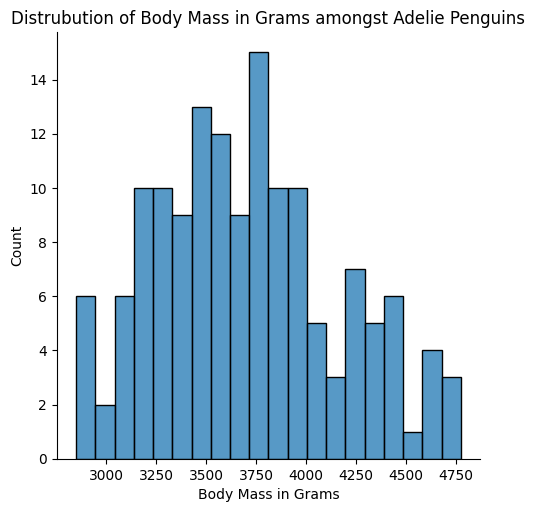

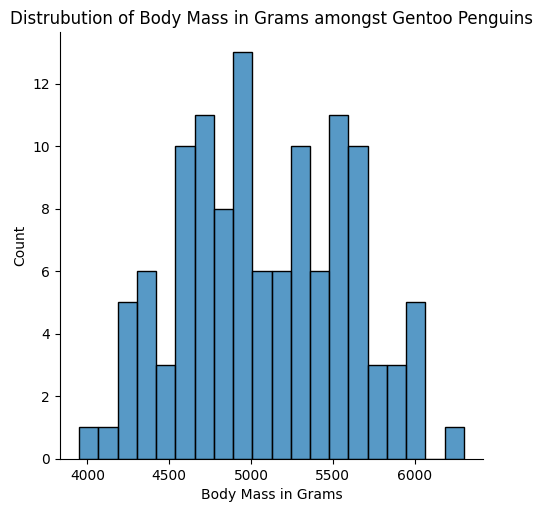

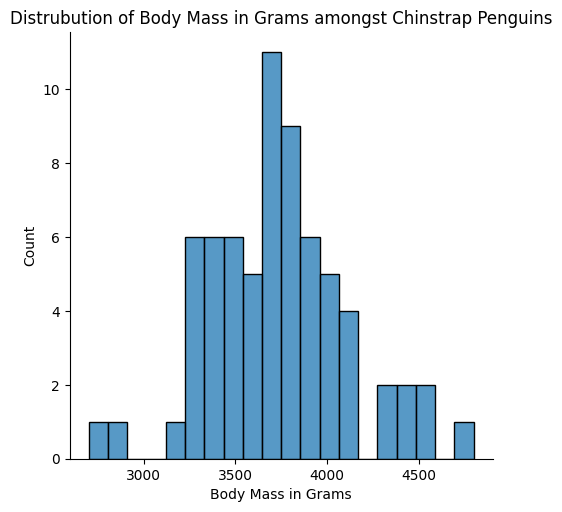

In [16]:
adelie_mass = sns.displot(data = penguins_clean[penguins_clean['species'] == 'Adelie'], x = 'body_mass_g', bins = 20)
plt.xlabel('Body Mass in Grams')
plt.title("Distrubution of Body Mass in Grams amongst Adelie Penguins")
plt.show()

gentoo_mass = sns.displot(data = penguins_clean[penguins_clean['species'] == 'Gentoo'], x = 'body_mass_g', bins = 20)
plt.xlabel('Body Mass in Grams')
plt.title("Distrubution of Body Mass in Grams amongst Gentoo Penguins")
plt.show()

chinstrap_mass = sns.displot(data = penguins_clean[penguins_clean['species'] == 'Chinstrap'], x = 'body_mass_g', bins = 20)
plt.xlabel('Body Mass in Grams')
plt.title("Distrubution of Body Mass in Grams amongst Chinstrap Penguins")
plt.show()

### Part 7) Boxplots of flipper length

Make a **single figure** with boxplots of `flipper_length_mm` by **species**.  

Briefly compare the medians and spreads in 2–3 sentences in a markdown cell.

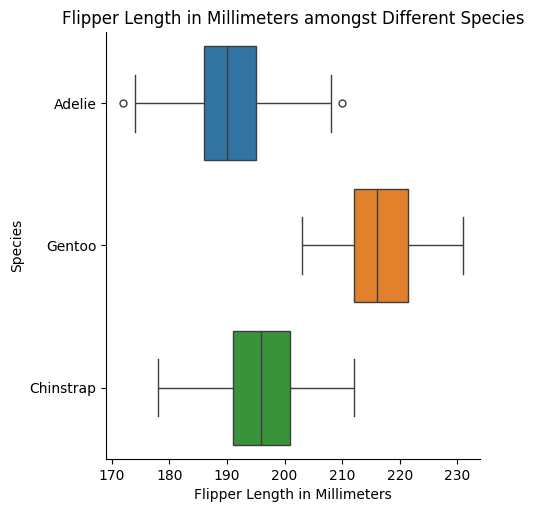

In [17]:
flippers_boxplot = sns.catplot(data = penguins_clean, x = "flipper_length_mm", y = "species", hue = 'species', kind = 'box')
plt.xlabel("Flipper Length in Millimeters")
plt.ylabel("Species")
plt.title("Flipper Length in Millimeters amongst Different Species")
plt.show()

It appears that Gentoo penguins have the highest typical flipper length amongst the three species, as the median flipper length for Gentoo penguins, which is somewhere around 215 mm, is much higher than that of Chinstrap and Adelie penguins, whose meedian flipper lengths are about 196 mm and 190 mm resspectively. Comparing the IQR's of the flipper lengths of the three species shows that they all have very similar spreads, which the IQR of each species appearing to be around 10 mm.

### Part 8) Scatter: bill length vs bill depth

- Make a scatter plot of **bill_length_mm** (x) vs **bill_depth_mm** (y), colored by species.
- Add a simple **linear fit line** per species
- Include a legend 

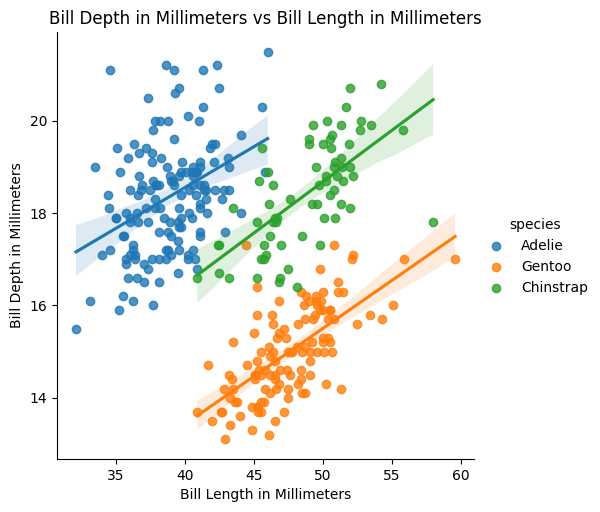

In [18]:
sns.lmplot(data = penguins_clean, x = "bill_length_mm", y = "bill_depth_mm", hue = "species")
plt.xlabel("Bill Length in Millimeters")
plt.ylabel("Bill Depth in Millimeters")
plt.title("Bill Depth in Millimeters vs Bill Length in Millimeters")
plt.show()

### Part 9) Stacked bars: sex proportions by species

Compute counts of `sex` within each `species`, convert to **proportions**, and make a **stacked bar chart**.  

- Bars should be species on the x‑axis with male/female proportions stacked to 1.0. 

In [19]:
prop_penguins = penguins_clean.groupby(["species"])["sex"].value_counts(normalize = True).reset_index(name = "prop")
prop_penguins = prop_penguins.pivot(index = "species", columns = "sex", values = "prop")
prop_penguins



sex,female,male
species,,
Adelie,0.500,0.500
Chinstrap,0.500,0.500
Gentoo,0.487,0.513


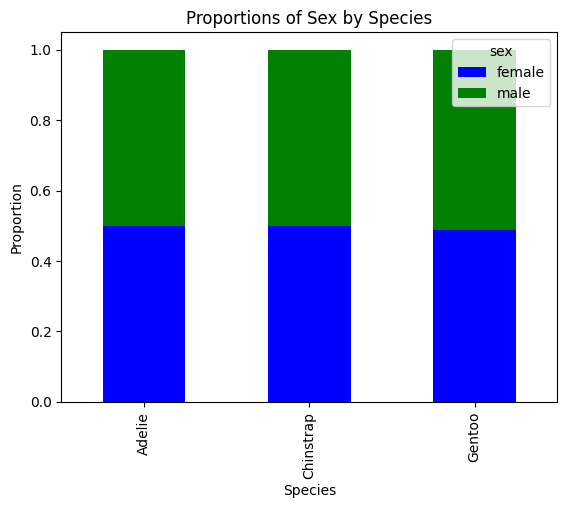

In [20]:
prop_penguins.plot.bar(stacked = "True", color = ['b', 'g'])
plt.title("Proportions of Sex by Species")
plt.ylabel("Proportion")
plt.xlabel("Species")
plt.show()